# Chapter 3 — Eye Candy: Volcano Plots Across Three Tissue Comparisons

**Chapter 3 | Elements of Style in Creating Workflows for Biomedical Research**

---

This notebook has one job: produce volcano plots that make you want to know more.

**The question:** Where does endometriosis leave a molecular signature —
and is it in the tissue that looks normal, or the tissue that has clearly gone wrong?

**The dataset:** GSE179640 — 24 bulk RNA-seq samples across four tissue types,
from 17 women (Tan et al., *Nature Cell Biology* 2022, PMID: 35864314):

| Group | n | Description |
|-------|---|-------------|
| **Ctrl** | 5 | Control eutopic endometrium — healthy women |
| **EuE** | 7 | Eutopic endometrium — women with endometriosis (looks normal) |
| **EcP** | 6 | Ectopic peritoneal lesions — endometriosis tissue, wrong location |
| **EcO** | 6 | Ectopic ovarian lesions — endometriosis tissue, wrong location |

**The method:** limma-voom with `duplicateCorrelation` to account for
matched donors (some patients contributed multiple tissue types).

**Three contrasts:**
- EuE vs Ctrl — does the "normal-looking" tissue differ?
- EcP vs Ctrl — how different are peritoneal lesions?
- EcO vs Ctrl — how different are ovarian lesions?

---

**Critical note:** This analysis is a starting point, not a conclusion.
Chapter 9 resolves the EuE question at single-cell resolution — the bulk signal
is subtle because cell-type-specific differences are averaged away.
See Squair et al. (2021) *Nature Communications* 12:5692 for why pseudobulk matters.

## Step 1 — Load libraries

Lesson 1: write clearly — one library per line, with a comment explaining why.

In [1]:
library(limma)            # linear models for microarrays and RNA-seq — Ritchie et al. (2015)
library(edgeR)            # TMM normalization, filterByExpr — Robinson et al. (2010)
library(EnhancedVolcano)  # publication-quality volcano plots — Blighe et al.
library(pheatmap)         # heatmaps
library(dplyr)            # data manipulation
library(readr)            # reading tabular data
library(ggplot2)          # additional plotting
library(ggrepel)          # non-overlapping text labels

set.seed(42)

Loading required package: ggplot2

Loading required package: ggrepel


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Step 2 — Define samples

All 24 bulk RNA-seq samples from GSE179640.
Each row is one sample. Each column tells us something about it.

Note the `patient` column: some patients contributed more than one tissue type.
P13 gave EuE + EcP + EcO. P16 gave EuE + EcP + EcO. P17 the same.
This matched structure is a strength — and we need to account for it in the model.

In [2]:
# All 24 bulk samples from GSE179640
# Source: GEO filelist.txt — https://ftp.ncbi.nlm.nih.gov/geo/series/GSE179nnn/GSE179640/suppl/filelist.txt
# Tan et al., Nature Cell Biology 2022. PMID: 35864314.

sample_info <- data.frame(
  sample_id = c(
    'Ctrl-P1','Ctrl-P4','Ctrl-P5','Ctrl-P6','Ctrl-P7',
    'EuE-P3','EuE-P7','EuE-P9','EuE-P13','EuE-P15','EuE-P16','EuE-P17',
    'EcP-P5','EcP-P10','EcP-P13','EcP-P14','EcP-P16','EcP-P17',
    'EcO-P7','EcO-P10','EcO-P13','EcO-P14','EcO-P16','EcO-P17'
  ),
  gsm = c(
    'GSM6102567','GSM6102568','GSM6102569','GSM6102570','GSM6102571',
    'GSM6102572','GSM6102575','GSM6102576','GSM6102581','GSM6102584','GSM6102587','GSM6102590',
    'GSM6102573','GSM6102578','GSM6102580','GSM6102583','GSM6102586','GSM6102589',
    'GSM6102574','GSM6102577','GSM6102579','GSM6102582','GSM6102585','GSM6102588'
  ),
  tissue_type = c(
    rep('Ctrl', 5), rep('EuE', 7), rep('EcP', 6), rep('EcO', 6)
  ),
  patient = c(
    'P1','P4','P5','P6','P7',
    'P3','P7','P9','P13','P15','P16','P17',
    'P5','P10','P13','P14','P16','P17',
    'P7','P10','P13','P14','P16','P17'
  ),
  stringsAsFactors = FALSE
)
rownames(sample_info) <- sample_info$sample_id
sample_info$tissue_type <- factor(sample_info$tissue_type, levels = c('Ctrl','EuE','EcP','EcO'))

cat('Sample breakdown:\n')
print(table(sample_info$tissue_type))
cat('\nPatients with multiple tissue types:\n')
print(table(sample_info$patient)[table(sample_info$patient) > 1])

Sample breakdown:

Ctrl  EuE  EcP  EcO 
   5    7    6    6 

Patients with multiple tissue types:

P10 P13 P14 P16 P17  P5  P7 
  2   3   2   3   3   2   3 


## Step 2b — Download the processed count data from GEO

Good science is reproducible. Part of what makes it reproducible is depositing your data.

Tan et al. did this correctly: they uploaded the raw FASTQs to SRA **and** the
processed featureCounts output to NCBI GEO (GSE179640), one file per sample.

**This is the same file your pipeline will produce in Chapter 7.**
When you align FASTQs with STAR and count reads with featureCounts,
you get exactly this format: one row per gene, one column of counts.

Here we download the 12 eutopic bulk samples directly from GEO —
no alignment needed, no pipeline needed yet.
Each file is ~4 MB. Total: ~50 MB, downloaded once and cached locally.

> GEO accession: [GSE179640](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE179640)

In [3]:
dir.create('data', showWarnings = FALSE)
cache_path <- 'data/counts_24sample_all_bulk.tsv'

if (!file.exists(cache_path)) {
  cat('Downloading all 24 featureCounts files from GEO (GSE179640)...\n')
  cat('Source: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE179640\n\n')

  geo_base <- 'https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6102nnn'

  # Confirmed from GEO filelist.txt
  geo_files <- c(
    'Ctrl-P1'  = 'GSM6102567/suppl/GSM6102567_C01_Ctrl_bulk.featurecounts.txt.gz',
    'Ctrl-P4'  = 'GSM6102568/suppl/GSM6102568_C04_Ctrl_bulk.featurecounts.txt.gz',
    'Ctrl-P5'  = 'GSM6102569/suppl/GSM6102569_C05_Ctrl_bulk.featurecounts.txt.gz',
    'Ctrl-P6'  = 'GSM6102570/suppl/GSM6102570_C06_Ctrl_bulk.featurecounts.txt.gz',
    'Ctrl-P7'  = 'GSM6102571/suppl/GSM6102571_C07_Ctrl_bulk.featurecounts.txt.gz',
    'EuE-P3'   = 'GSM6102572/suppl/GSM6102572_E03_EuE_bulk.featurecounts.txt.gz',
    'EuE-P7'   = 'GSM6102575/suppl/GSM6102575_E07_EuE_bulk.featurecounts.txt.gz',
    'EuE-P9'   = 'GSM6102576/suppl/GSM6102576_E09_EuE_bulk.featurecounts.txt.gz',
    'EuE-P13'  = 'GSM6102581/suppl/GSM6102581_E13_EuE_bulk.featurecounts.txt.gz',
    'EuE-P15'  = 'GSM6102584/suppl/GSM6102584_E15_EuE_bulk.featurecounts.txt.gz',
    'EuE-P16'  = 'GSM6102587/suppl/GSM6102587_E16_EuE_bulk.featurecounts.txt.gz',
    'EuE-P17'  = 'GSM6102590/suppl/GSM6102590_E17_EuE_bulk.featurecounts.txt.gz',
    'EcP-P5'   = 'GSM6102573/suppl/GSM6102573_E05_EcP_bulk.featurecounts.txt.gz',
    'EcP-P10'  = 'GSM6102578/suppl/GSM6102578_E10_EcP_bulk.featurecounts.txt.gz',
    'EcP-P13'  = 'GSM6102580/suppl/GSM6102580_E13_EcP_bulk.featurecounts.txt.gz',
    'EcP-P14'  = 'GSM6102583/suppl/GSM6102583_E14_EcP_bulk.featurecounts.txt.gz',
    'EcP-P16'  = 'GSM6102586/suppl/GSM6102586_E16_EcP_bulk.featurecounts.txt.gz',
    'EcP-P17'  = 'GSM6102589/suppl/GSM6102589_E17_EcP_bulk.featurecounts.txt.gz',
    'EcO-P7'   = 'GSM6102574/suppl/GSM6102574_E07_EcO_bulk.featurecounts.txt.gz',
    'EcO-P10'  = 'GSM6102577/suppl/GSM6102577_E10_EcO_bulk.featurecounts.txt.gz',
    'EcO-P13'  = 'GSM6102579/suppl/GSM6102579_E13_EcO_bulk.featurecounts.txt.gz',
    'EcO-P14'  = 'GSM6102582/suppl/GSM6102582_E14_EcO_bulk.featurecounts.txt.gz',
    'EcO-P16'  = 'GSM6102585/suppl/GSM6102585_E16_EcO_bulk.featurecounts.txt.gz',
    'EcO-P17'  = 'GSM6102588/suppl/GSM6102588_E17_EcO_bulk.featurecounts.txt.gz'
  )

  counts_list <- list()
  gene_meta   <- NULL

  for (sid in names(geo_files)) {
    url <- paste0(geo_base, '/', geo_files[sid])
    cat(sprintf('  %-12s %s\n', sid, basename(geo_files[sid])))
    tryCatch({
      df        <- read_tsv(url, skip = 1, show_col_types = FALSE)
      count_col <- colnames(df)[ncol(df)]
      if (is.null(gene_meta)) gene_meta <- df[, c('Geneid', 'gene_name')]
      counts_list[[sid]] <- df[[count_col]]
    }, error = function(e) {
      stop(sprintf('Failed on %s: %s', sid, conditionMessage(e)))
    })
  }

  # check.names = FALSE preserves hyphens in column names (e.g. 'Ctrl-P1').
  # Without it, as.data.frame() calls make.names() and silently converts to 'Ctrl.P1'.
  counts_df <- dplyr::bind_cols(gene_meta, as.data.frame(counts_list, check.names = FALSE))
  write_tsv(counts_df, cache_path)
  cat(sprintf('\nSaved: %s  (%d genes x %d samples)\n',
              cache_path, nrow(counts_df), length(counts_list)))

} else {
  cat('Using cached count matrix:', cache_path, '\n')
  counts_df <- read_tsv(cache_path, show_col_types = FALSE)
  cat(sprintf('  %d genes x %d samples\n', nrow(counts_df), ncol(counts_df) - 2))
}

# Normalize column names: if this is an old cache saved before the check.names fix,
# column names will be 'Ctrl.P1' (dots) instead of 'Ctrl-P1' (hyphens).
# chartr converts dots back to hyphens; safe because Geneid and gene_name have no dots.
colnames(counts_df) <- chartr('.', '-', colnames(counts_df))

Using cached count matrix: data/counts_24sample_all_bulk.tsv 
  33538 genes x 24 samples


In [4]:
# Build count matrix: rows = genes (gene_name), columns = samples (sample_id)
# counts_df has: Geneid, gene_name, Ctrl-P1, ..., EcO-P17
#
# Order matters in the pipe:
#   1. add row_id (unique gene symbol)
#   2. select only row_id + sample columns  ← drop Geneid and gene_name first
#   3. set row_id as rownames
#   4. convert to matrix
counts <- counts_df |>
  dplyr::mutate(row_id = make.unique(gene_name)) |>
  dplyr::select(row_id, all_of(rownames(sample_info))) |>
  tibble::column_to_rownames('row_id') |>
  as.matrix()

stopifnot(
  'Expected 24 samples'         = ncol(counts) == 24,
  'Counts must be non-negative' = all(counts >= 0, na.rm = TRUE)
)
cat('Count matrix:', nrow(counts), 'genes x', ncol(counts), 'samples\n')
cat('Gene names: HGNC symbols from featureCounts (Ensembl GRCh38)\n')

Count matrix: 33538 genes x 24 samples
Gene names: HGNC symbols from featureCounts (Ensembl GRCh38)


## Step 3 — limma-voom: normalize, weight, model

**Why limma-voom, not DESeq2?**

DESeq2 is excellent. But limma-voom handles complex designs more naturally,
and at n=5–7 per group, the empirical Bayes shrinkage in `eBayes` gives
better-calibrated results than DESeq2's dispersion shrinkage for small n.

**The steps:**

1. **`DGEList`** — package counts + sample metadata together  
2. **`filterByExpr`** — remove genes too lowly expressed to test reliably  
3. **`calcNormFactors(TMM)`** — TMM normalization: corrects for compositional differences between libraries (the same idea as DESeq2's size factors, different math)  
4. **`voom`** — converts counts to log-CPM with per-observation precision weights; the weights account for the mean-variance relationship in count data  
5. **`duplicateCorrelation`** — estimates the within-donor correlation across the samples that share a patient; this is how we use the matched structure without over-fitting  
6. **`lmFit` → `contrasts.fit` → `eBayes`** — fit the linear model, apply contrasts, shrink variance estimates  

**The design:** `~ 0 + tissue_type` — no intercept, four group means.
The contrasts then ask: EuE − Ctrl, EcP − Ctrl, EcO − Ctrl.

Genes after filterByExpr: 19063 
TMM normalization factors (should be near 1.0):
 [1] 1.192 1.008 0.772 1.028 1.010 1.303 1.206 1.180 1.087 1.017 0.921 0.874
[13] 1.105 0.980 1.068 0.948 0.962 0.741 1.016 0.988 1.003 0.918 0.806 1.082

voom mean-variance trend (points should follow the red curve):

Inter-donor correlation (consensus): 0.005 
(A positive value confirms that samples from the same donor are more similar to each other)


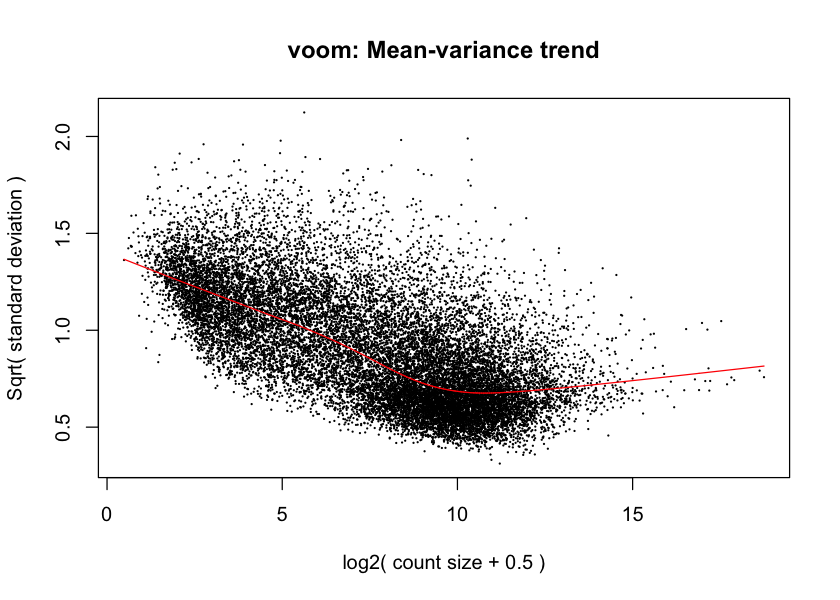

In [5]:
# 1. DGEList
dge <- DGEList(counts = counts, samples = sample_info)

# 2. Filter lowly expressed genes
#    filterByExpr keeps genes with sufficient counts in the smallest group
keep <- filterByExpr(dge, group = dge$samples$tissue_type)
dge  <- dge[keep, , keep.lib.sizes = FALSE]
cat('Genes after filterByExpr:', nrow(dge), '\n')

# 3. TMM normalization
dge <- calcNormFactors(dge, method = 'TMM')
cat('TMM normalization factors (should be near 1.0):\n')
print(round(dge$samples$norm.factors, 3))

# 4. Design matrix: four group means, no intercept
design <- model.matrix(~ 0 + tissue_type, data = sample_info)
colnames(design) <- levels(sample_info$tissue_type)

# 5. voom — renders the mean-variance trend plot inline
options(repr.plot.width = 7, repr.plot.height = 5)
cat('\nvoom mean-variance trend (points should follow the red curve):\n')
v <- voom(dge, design, plot = TRUE)

# 6. duplicateCorrelation — within-donor correlation for matched samples
corfit <- duplicateCorrelation(v, design, block = sample_info$patient)
cat('\nInter-donor correlation (consensus):', round(corfit$consensus, 3), '\n')
cat('(A positive value confirms that samples from the same donor are more similar to each other)\n')

In [6]:
# Fit linear model with donor blocking
fit <- lmFit(v, design,
             block       = sample_info$patient,
             correlation = corfit$consensus)

# Define three contrasts
contrasts_mat <- makeContrasts(
  EuE_vs_Ctrl = EuE - Ctrl,
  EcP_vs_Ctrl = EcP - Ctrl,
  EcO_vs_Ctrl = EcO - Ctrl,
  levels = design
)

fit2 <- contrasts.fit(fit, contrasts_mat)
fit2 <- eBayes(fit2)

# Extract results for each contrast
# number = Inf returns all genes (not just the default top 10)
res_list <- list(
  EuE_vs_Ctrl = topTable(fit2, coef = 'EuE_vs_Ctrl', number = Inf, sort.by = 'P') |>
    tibble::rownames_to_column('gene'),
  EcP_vs_Ctrl = topTable(fit2, coef = 'EcP_vs_Ctrl', number = Inf, sort.by = 'P') |>
    tibble::rownames_to_column('gene'),
  EcO_vs_Ctrl = topTable(fit2, coef = 'EcO_vs_Ctrl', number = Inf, sort.by = 'P') |>
    tibble::rownames_to_column('gene')
)

# Summary
cat('Significant DE genes (adj.P.Val < 0.05, |logFC| >= 1):\n')
for (nm in names(res_list)) {
  sig <- sum(res_list[[nm]]$adj.P.Val < 0.05 & abs(res_list[[nm]]$logFC) >= 1)
  cat(sprintf('  %-15s %d genes\n', nm, sig))
}
cat('\nTop 5 genes — EcP vs Ctrl:\n')
print(head(res_list$EcP_vs_Ctrl[, c('gene','logFC','AveExpr','t','adj.P.Val')], 5))

Significant DE genes (adj.P.Val < 0.05, |logFC| >= 1):
  EuE_vs_Ctrl     0 genes
  EcP_vs_Ctrl     2060 genes
  EcO_vs_Ctrl     2284 genes

Top 5 genes — EcP vs Ctrl:
       gene     logFC   AveExpr         t    adj.P.Val
1     SYNPO  4.155020  6.375189 10.308366 6.722889e-06
2        C7  7.907170  6.629960  9.597419 9.372276e-06
3 LINC00842  5.126559 -3.296328  9.307560 9.372276e-06
4     CPXM2  5.962491  4.225802  9.304990 9.372276e-06
5    SMIM31 -7.216551 -1.940426 -9.300549 9.372276e-06


## Step 4 — Three Volcano Plots

One plot per contrast. Read them left to right.

The EuE plot answers: *does the tissue that looks normal have a molecular signal?*
The EcP and EcO plots answer: *how different are the lesions?*

The contrast in scale between the three plots is itself the result.

---

### A note on what you see — and what you don't

The **volcano plot** and the **heatmap** answer different questions.
Understanding why they show different genes is itself a lesson.

**The volcano plot** ranks genes by the combination of fold change (x-axis)
and statistical significance (y-axis). A gene can appear prominently on the
volcano even if it is expressed at very low levels — as long as the fold
change is large and consistent across samples.

**The heatmap** shows the top genes by adjusted p-value, but genes with
low average expression have lower statistical power and tend to fall
down the ranked list, even if their fold change is dramatic.

**LINC00982 / PRDM16-DT** is a perfect example.
In the EcP vs Ctrl volcano, it sits far to the upper right:
- log₂ fold change = **+7.0** — among the most upregulated genes
- Average expression = **−1.96 log-CPM** — nearly absent in controls,
  only expressed in ectopic peritoneal tissue

It appears on the volcano. It does not appear in the heatmap top 40.
Both are correct. They are showing you different aspects of the same result.

---

### LINC00982 / PRDM16-DT — a lesson in annotation

LINC00982 was classified as a long non-coding RNA (lncRNA) in early
genome annotations. Recent research has identified that it is actually
a divergent transcript of **PRDM16** (PR domain containing 16) —
now called **PRDM16-DT** — and that it encodes a functional
**148-amino acid protein**.

PRDM16 is a master transcriptional regulator of mesenchymal cell identity:
smooth muscle, adipocyte, and cardiac fate decisions. Finding PRDM16-DT
highly upregulated in ectopic peritoneal lesions is biologically coherent —
these cells are undergoing exactly the kind of mesenchymal reprogramming
that PRDM16 governs.

**Why was it called a lncRNA in the first place?**

Short-read Illumina sequencing (150 bp reads) cannot span a full transcript.
Assembling a transcript from short fragments often misses small open reading
frames, particularly those in divergent or antisense orientations.
The gene didn't change — our ability to read it did.

This is one of many cases where the annotation says "non-coding" but the
biology disagrees. Long-read sequencing (PacBio, Oxford Nanopore) and
ribosome profiling are correcting these classifications systematically.

> *"The map is not the territory.
> The genome annotation is not the genome."*

PRDM16 itself also appears in our top hits (logFC = +4.7, adj.P = 4.2×10⁻⁴).
The regulatory gene and its divergent transcript are both upregulated
in the same tissue. That is not a coincidence.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'log₂ fold change' in 'mbcsToSbcs': for ₂ (U+2082)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '-log₁₀ adjusted p-value' in 'mbcsToSbcs': for ₁ (U+2081)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '-log₁₀ adjusted p-value' in 'mbcsToSbcs': for ₀ (U+2080)”


Saved: volcano_EuE_vs_Ctrl.pdf


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'log₂ fold change' in 'mbcsToSbcs': for ₂ (U+2082)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '-log₁₀ adjusted p-value' in 'mbcsToSbcs': for ₁ (U+2081)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '-log₁₀ adjusted p-value' in 'mbcsToSbcs': for ₀ (U+2080)”


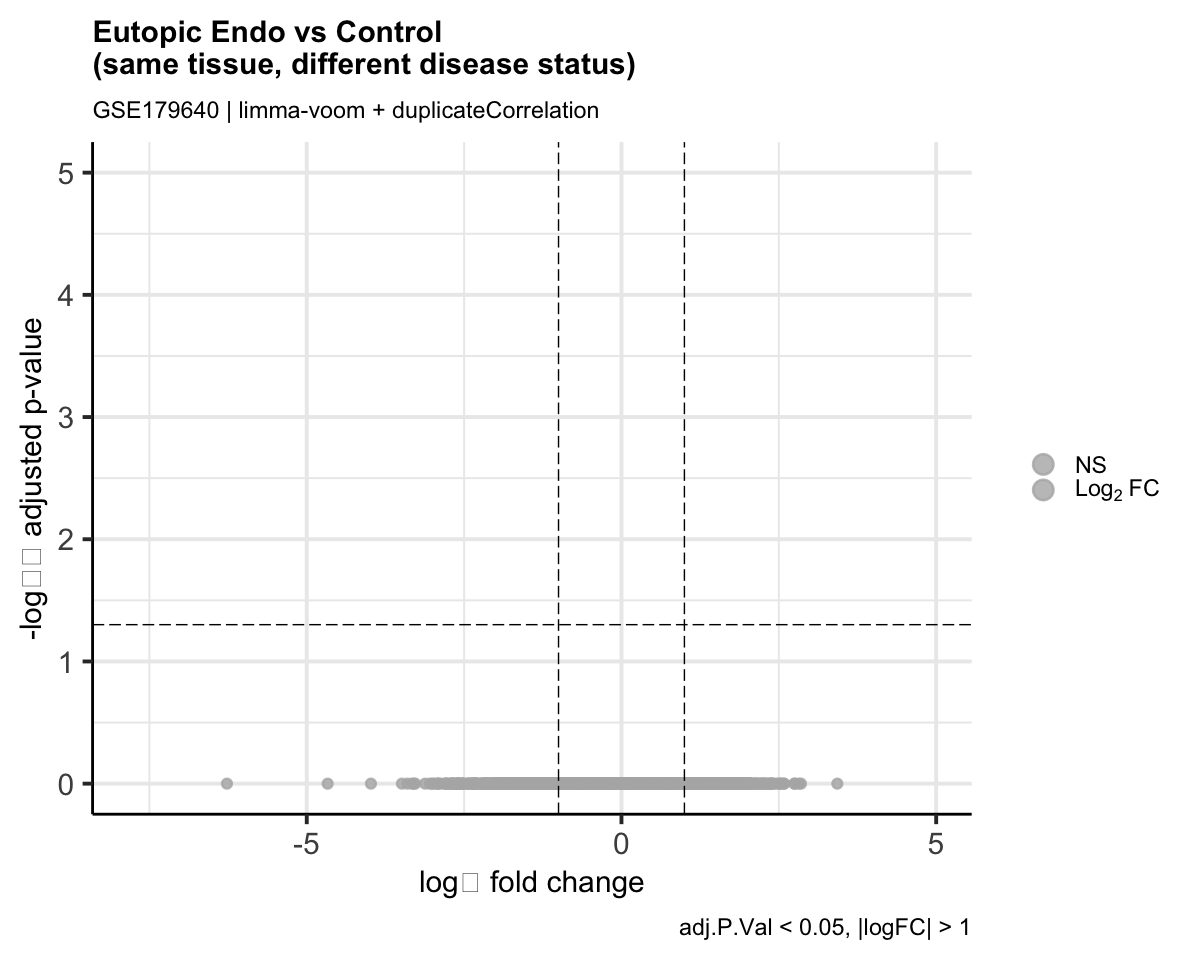

Saved: volcano_EcP_vs_Ctrl.pdf


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'log₂ fold change' in 'mbcsToSbcs': for ₂ (U+2082)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '-log₁₀ adjusted p-value' in 'mbcsToSbcs': for ₁ (U+2081)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '-log₁₀ adjusted p-value' in 'mbcsToSbcs': for ₀ (U+2080)”


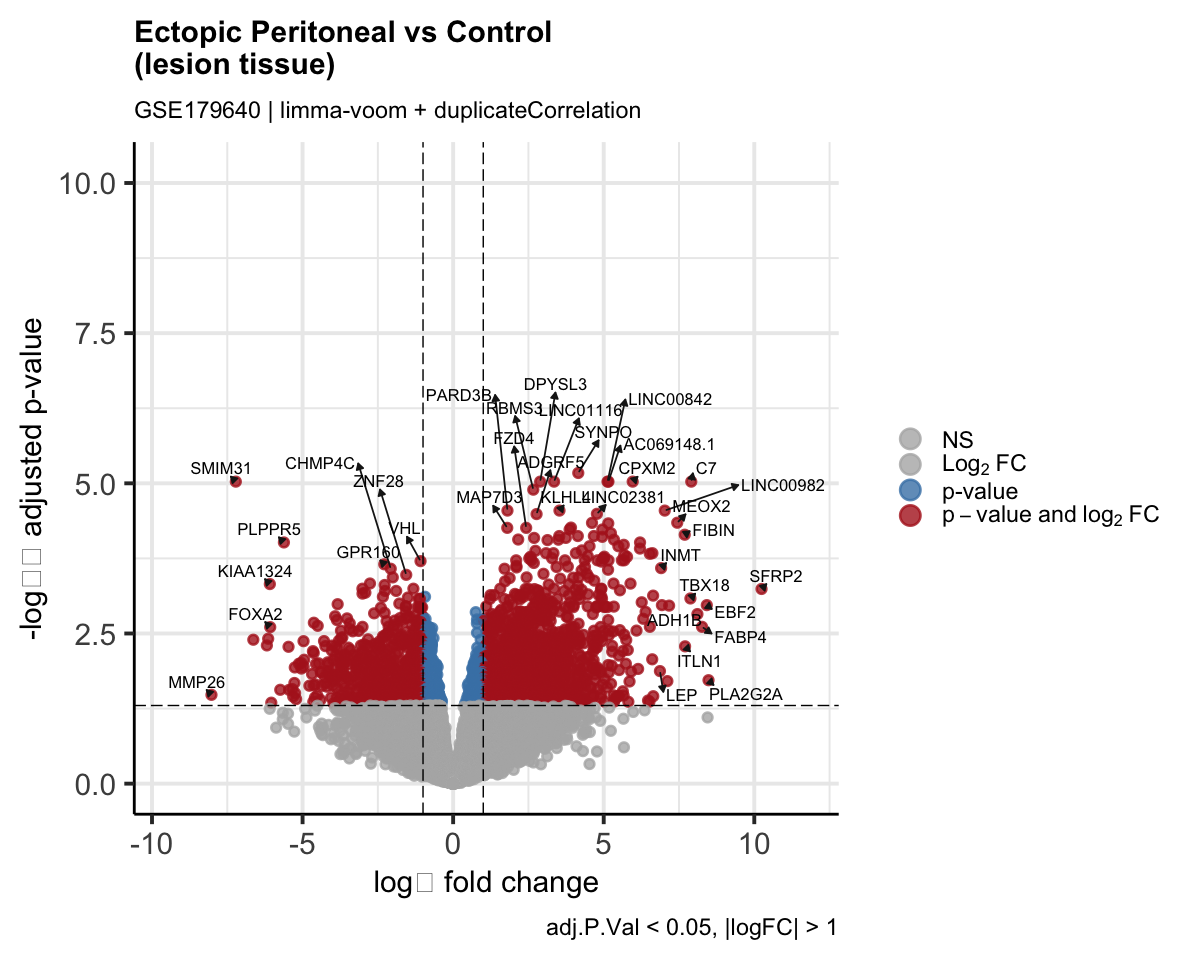

Saved: volcano_EcO_vs_Ctrl.pdf


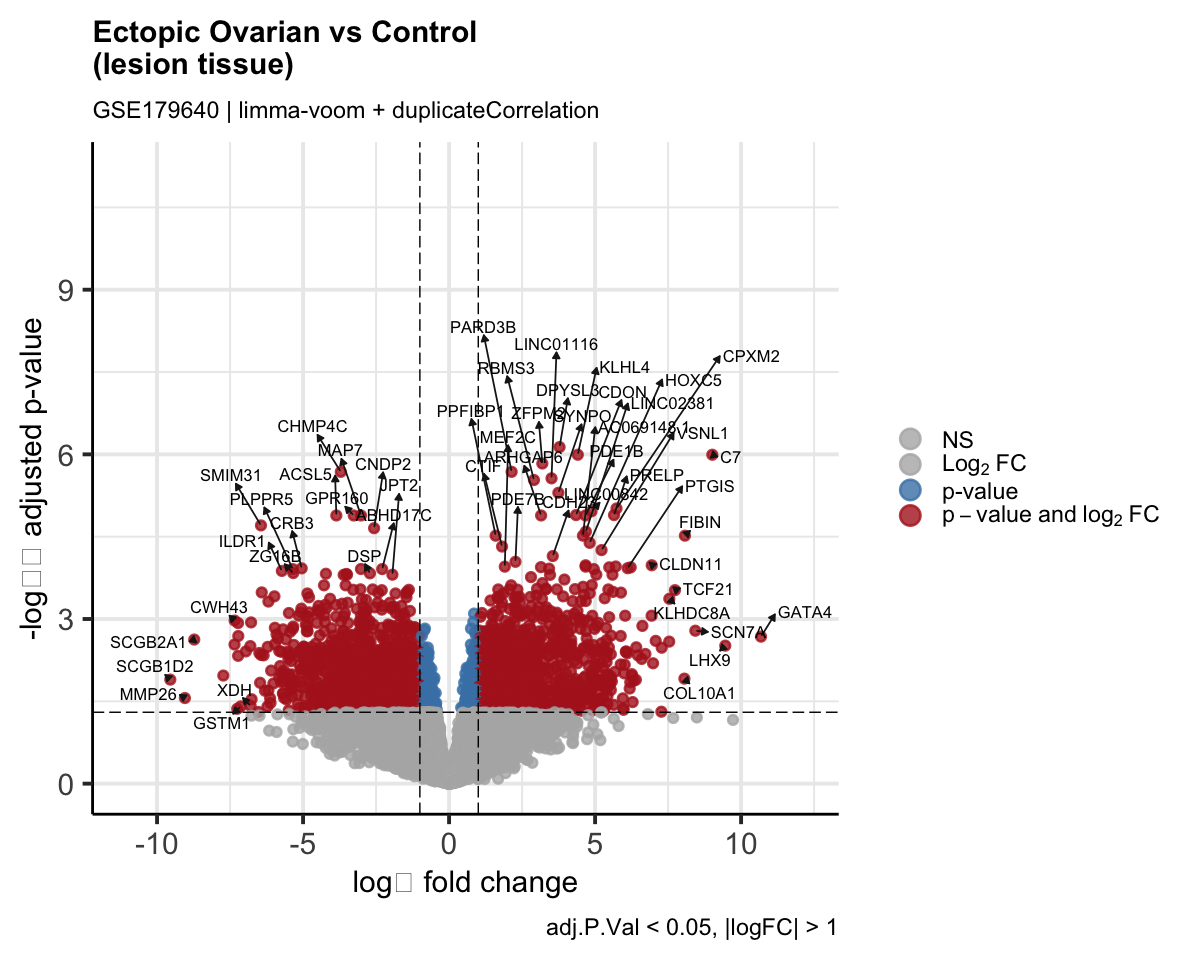

In [7]:
volcano_titles <- c(
  EuE_vs_Ctrl = 'Eutopic Endo vs Control\n(same tissue, different disease status)',
  EcP_vs_Ctrl = 'Ectopic Peritoneal vs Control\n(lesion tissue)',
  EcO_vs_Ctrl = 'Ectopic Ovarian vs Control\n(lesion tissue)'
)

options(repr.plot.width = 10, repr.plot.height = 8)

for (nm in names(res_list)) {
  df <- res_list[[nm]]

  p <- EnhancedVolcano(
    df,
    lab            = df$gene,
    x              = 'logFC',
    y              = 'adj.P.Val',
    title          = volcano_titles[nm],
    subtitle       = 'GSE179640 | limma-voom + duplicateCorrelation',
    caption        = 'adj.P.Val < 0.05, |logFC| > 1',
    xlab           = 'log\u2082 fold change',
    ylab           = '-log\u2081\u2080 adjusted p-value',
    pCutoff        = 0.05,
    FCcutoff       = 1.0,
    pointSize      = 2.0,
    labSize        = 3.5,
    col            = c('grey70','grey70','steelblue','firebrick'),
    colAlpha       = 0.8,
    legendPosition = 'right',
    drawConnectors = TRUE,
    max.overlaps   = 25
  )
  print(p)
  ggsave(paste0('volcano_', nm, '.pdf'), plot = p, width = 10, height = 8)
  cat('Saved: volcano_', nm, '.pdf\n', sep = '')
}

## Step 5 — Heatmap of top DE genes across all 24 samples

Top 40 genes from the EcP vs Ctrl contrast, z-scored and clustered.
All 24 samples shown — the heatmap tells you whether EuE and EcO
behave like EcP or like Ctrl.

Known endometriosis markers (from the literature and Tan et al. 2022)
are annotated on the right-hand axis.
If they appear in our top hits, we are recapitulating the paper.

In [8]:
top_genes <- res_list$EcP_vs_Ctrl |>
  filter(adj.P.Val < 0.05, abs(logFC) >= 1) |>
  arrange(adj.P.Val) |>
  head(40) |>
  pull(gene)

cat('Top DE genes for heatmap (EcP vs Ctrl):', length(top_genes), '\n')

if (length(top_genes) >= 2) {
  # voom log-CPM values — already normalized, appropriate for visualization
  mat        <- v$E[top_genes, ]
  mat_scaled <- t(scale(t(mat)))  # z-score per gene

  # ── Sample annotation ────────────────────────────────────────────────────
  annotation_col <- data.frame(
    Tissue  = sample_info$tissue_type,
    Patient = sample_info$patient,
    row.names = rownames(sample_info)
  )
  annotation_colors <- list(
    Tissue = c(Ctrl = 'steelblue', EuE = 'goldenrod2',
               EcP  = 'firebrick', EcO  = 'darkred')
  )

  # ── Gene annotation: flag known endometriosis markers ───────────────────
  # Selected from Tan et al. 2022 (NatCellBiol) and endometriosis bulk RNA-seq literature
  known_markers <- c(
    'VEGFA','MMP2','MMP9','MMP11','MMP14',      # angiogenesis / invasion
    'IL6','CXCL8','TNF','IL1B',                  # inflammation
    'ACTA2','FN1','VIM','POSTN','SPARC','CDH11', # stromal / ECM remodeling
    'PGR','HOXA10','HOXA11','ESR1',              # hormone response (often down in ectopic)
    'PDGFRA','PDGFRB','PECAM1'                   # mesenchymal / vascular
  )
  # Use a named factor — avoids the empty-string key bug in pheatmap annotation_colors
  gene_annotation <- data.frame(
    Marker = factor(
      ifelse(top_genes %in% known_markers, 'Known marker', 'Other'),
      levels = c('Known marker', 'Other')
    ),
    row.names = top_genes
  )
  annotation_row_colors <- list(
    Marker = c('Known marker' = 'darkorange', 'Other' = 'grey90')
  )

  colnames(mat_scaled) <- rownames(sample_info)

  # ── Render inline using grid.draw (most reliable in Jupyter) ─────────────
  options(repr.plot.width = 15, repr.plot.height = 10)

  ph <- pheatmap(
    mat_scaled,
    annotation_col    = annotation_col,
    annotation_row    = gene_annotation,
    annotation_colors = c(annotation_colors, annotation_row_colors),
    cluster_rows      = TRUE,
    cluster_cols      = TRUE,
    show_rownames     = TRUE,
    show_colnames     = TRUE,
    fontsize_row      = 8,
    fontsize_col      = 7,
    main              = 'Top DE genes: EcP vs Ctrl — GSE179640 (Tan et al. 2022)',
    silent            = TRUE
  )

  grid::grid.newpage()
  grid::grid.draw(ph$gtable)

  # ── Save to PDF ───────────────────────────────────────────────────────────
  pheatmap(
    mat_scaled,
    annotation_col    = annotation_col,
    annotation_row    = gene_annotation,
    annotation_colors = c(annotation_colors, annotation_row_colors),
    cluster_rows      = TRUE,
    cluster_cols      = TRUE,
    show_rownames     = TRUE,
    show_colnames     = TRUE,
    fontsize_row      = 8,
    fontsize_col      = 7,
    main              = 'Top DE genes: EcP vs Ctrl — GSE179640 (Tan et al. 2022)',
    filename          = 'heatmap_EcP_vs_Ctrl.pdf',
    width             = 15,
    height            = 10
  )
  cat('Saved: heatmap_EcP_vs_Ctrl.pdf\n')

  known_in_top <- intersect(top_genes, known_markers)
  cat('\nKnown endometriosis markers in top 40 genes:\n')
  if (length(known_in_top) > 0) {
    cat(' ', paste(known_in_top, collapse = ', '), '\n')
  } else {
    cat('  (none in top 40 — present further down the ranked list)\n')
  }
}

Top DE genes for heatmap (EcP vs Ctrl): 40 


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Top DE genes: EcP vs Ctrl — GSE179640 (Tan et al. 2022)' in 'mbcsToSbcs': - substituted for — (U+2014)”


Saved: heatmap_EcP_vs_Ctrl.pdf

Known endometriosis markers in top 40 genes:
  (none in top 40 — present further down the ranked list)


## Step 6 — Venn diagram: shared vs unique DE genes in EcP and EcO

Both ectopic tissue types are displaced endometrium — but they are in
different anatomical locations (peritoneum vs ovary) under different
microenvironmental pressures.

**The question:** Are EcP and EcO transcriptionally similar, or have they
diverged? Do they share a common ectopic signature, or has each developed
independently?

A Venn diagram of the significant DE genes answers this directly.
Two panels: upregulated genes (logFC ≥ 1) and downregulated genes (logFC ≤ −1),
each vs Ctrl at adj.P.Val < 0.05.

Upregulated (logFC >= 1, adj.P < 0.05):
  EcP:         1332 genes
  EcO:         1142 genes
  Shared:      654 genes  (49% of EcP, 57% of EcO)

Downregulated (logFC <= -1, adj.P < 0.05):
  EcP:         728 genes
  EcO:         1142 genes
  Shared:      486 genes  (67% of EcP, 43% of EcO)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'limma-voom | adj.P.Val < 0.05 | |log₂FC| ≥ 1' in 'mbcsToSbcs': for ₂ (U+2082)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'limma-voom | adj.P.Val < 0.05 | |log₂FC| ≥ 1' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”



Saved: venn_EcP_EcO_vs_Ctrl.pdf

Shared upregulated genes — biologically notable:
  LINC00982
  PRDM16
  ACTA2
  MYH11
  TAGLN
  DCN
  SFRP2
  WISP2
  C3
  C7
  C1S
  C1R
  CXCL12
  VCAM1
  SERPINE1
  ENG
  GATA6
  MEF2C
  TCF21
  PTGIS
  AQP1
  VEGFB 


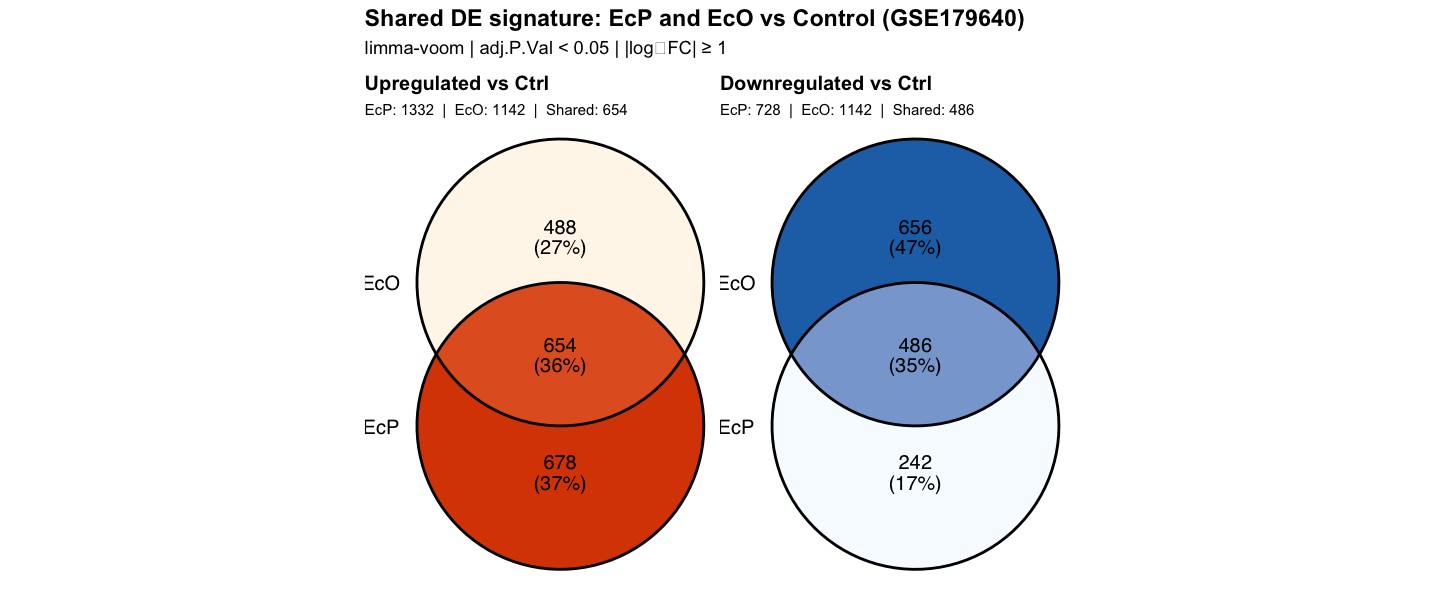

In [9]:
library(ggVennDiagram)   # Venn diagrams as ggplot objects — Chen et al.
library(patchwork)       # combine ggplot panels side by side

# ── Define gene sets ────────────────────────────────────────────────────────
EcP_up   <- res_list$EcP_vs_Ctrl |> filter(adj.P.Val < 0.05, logFC >=  1) |> pull(gene)
EcP_down <- res_list$EcP_vs_Ctrl |> filter(adj.P.Val < 0.05, logFC <= -1) |> pull(gene)
EcO_up   <- res_list$EcO_vs_Ctrl |> filter(adj.P.Val < 0.05, logFC >=  1) |> pull(gene)
EcO_down <- res_list$EcO_vs_Ctrl |> filter(adj.P.Val < 0.05, logFC <= -1) |> pull(gene)

cat('Upregulated (logFC >= 1, adj.P < 0.05):\n')
cat(sprintf('  EcP:         %d genes\n', length(EcP_up)))
cat(sprintf('  EcO:         %d genes\n', length(EcO_up)))
cat(sprintf('  Shared:      %d genes  (%.0f%% of EcP, %.0f%% of EcO)\n',
    length(intersect(EcP_up, EcO_up)),
    100 * length(intersect(EcP_up, EcO_up)) / length(EcP_up),
    100 * length(intersect(EcP_up, EcO_up)) / length(EcO_up)))

cat('\nDownregulated (logFC <= -1, adj.P < 0.05):\n')
cat(sprintf('  EcP:         %d genes\n', length(EcP_down)))
cat(sprintf('  EcO:         %d genes\n', length(EcO_down)))
cat(sprintf('  Shared:      %d genes  (%.0f%% of EcP, %.0f%% of EcO)\n',
    length(intersect(EcP_down, EcO_down)),
    100 * length(intersect(EcP_down, EcO_down)) / length(EcP_down),
    100 * length(intersect(EcP_down, EcO_down)) / length(EcO_down)))

# ── Venn plots ───────────────────────────────────────────────────────────────
options(repr.plot.width = 12, repr.plot.height = 5)

p_up <- ggVennDiagram(
  list(EcP = EcP_up, EcO = EcO_up),
  label_alpha = 0,
  edge_size   = 0.8
) +
  scale_fill_gradient(low = '#fff7ec', high = '#d94701') +
  labs(title = 'Upregulated vs Ctrl',
       subtitle = sprintf('EcP: %d  |  EcO: %d  |  Shared: %d',
                          length(EcP_up), length(EcO_up),
                          length(intersect(EcP_up, EcO_up)))) +
  theme(legend.position = 'none',
        plot.title    = element_text(size = 12, face = 'bold'),
        plot.subtitle = element_text(size = 9))

p_down <- ggVennDiagram(
  list(EcP = EcP_down, EcO = EcO_down),
  label_alpha = 0,
  edge_size   = 0.8
) +
  scale_fill_gradient(low = '#f7fbff', high = '#2171b5') +
  labs(title = 'Downregulated vs Ctrl',
       subtitle = sprintf('EcP: %d  |  EcO: %d  |  Shared: %d',
                          length(EcP_down), length(EcO_down),
                          length(intersect(EcP_down, EcO_down)))) +
  theme(legend.position = 'none',
        plot.title    = element_text(size = 12, face = 'bold'),
        plot.subtitle = element_text(size = 9))

p_venn <- p_up + p_down +
  plot_annotation(
    title    = 'Shared DE signature: EcP and EcO vs Control (GSE179640)',
    subtitle = 'limma-voom | adj.P.Val < 0.05 | |log₂FC| ≥ 1',
    theme    = theme(plot.title = element_text(size = 14, face = 'bold'))
  )

p_venn

ggsave('venn_EcP_EcO_vs_Ctrl.pdf', plot = p_venn, width = 12, height = 5)
cat('\nSaved: venn_EcP_EcO_vs_Ctrl.pdf\n')

# ── Shared upregulated genes of biological interest ──────────────────────────
cat('\nShared upregulated genes — biologically notable:\n')
highlight <- c('LINC00982','PRDM16','ACTA2','MYH11','TAGLN',  # mesenchymal / smooth muscle
               'DCN','SFRP2','POSTN','WISP2',                  # stromal ECM
               'C3','C7','C1S','C1R',                          # complement
               'CXCL12','VCAM1','SERPINE1','ENG',              # vascular / inflammatory
               'HOXA10','HOXA11','GATA6','MEF2C','TCF21',      # transcription factors
               'PTGIS','AQP1','VEGFB')                         # vascular biology
shared_up <- intersect(EcP_up, EcO_up)
found <- intersect(highlight, shared_up)
cat(paste(' ', found, collapse = '\n'), '\n')

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'PCA — all 24 bulk samples (GSE179640)' in 'mbcsToSbcs': - substituted for — (U+2014)”


Saved: pca_all24_bulk.pdf


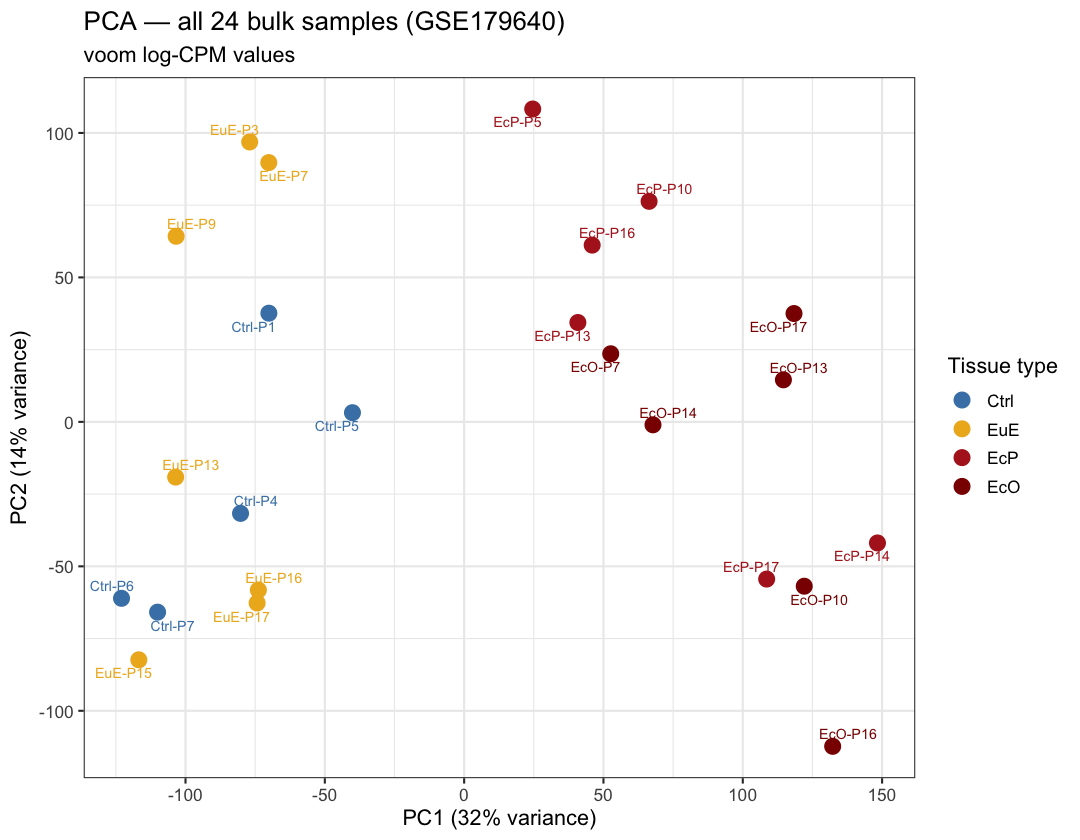

In [10]:
# PCA on voom log-CPM values (all 24 samples, all groups)
pca_res     <- prcomp(t(v$E), scale. = FALSE)
percent_var <- round(100 * pca_res$sdev^2 / sum(pca_res$sdev^2))

pca_df <- as.data.frame(pca_res$x[, 1:2])
pca_df$sample_id   <- rownames(pca_df)
pca_df$tissue_type <- sample_info[pca_df$sample_id, 'tissue_type']
pca_df$patient     <- sample_info[pca_df$sample_id, 'patient']

options(repr.plot.width = 9, repr.plot.height = 7)

p_pca <- ggplot(pca_df, aes(PC1, PC2, color = tissue_type, label = sample_id)) +
  geom_point(size = 4) +
  geom_text_repel(size = 3, max.overlaps = 30) +
  scale_color_manual(
    values = c(Ctrl = 'steelblue', EuE = 'goldenrod2',
               EcP  = 'firebrick', EcO = 'darkred')
  ) +
  labs(
    title  = 'PCA — all 24 bulk samples (GSE179640)',
    subtitle = 'voom log-CPM values',
    x      = paste0('PC1 (', percent_var[1], '% variance)'),
    y      = paste0('PC2 (', percent_var[2], '% variance)'),
    color  = 'Tissue type'
  ) +
  theme_bw(base_size = 13)

p_pca

ggsave('pca_all24_bulk.pdf', plot = p_pca, width = 9, height = 7)
cat('Saved: pca_all24_bulk.pdf\n')

## Step 7 — Significant gene lists (FC > 8, adj.P < 0.05)

We apply two widely-used thresholds:
- **Fold-change > 8** (log₂FC > 3.0) — a stringent threshold that isolates the most dramatic expression changes
- **Adjusted p-value < 0.05** — Benjamini–Hochberg FDR control

EuE vs Ctrl produces **zero** significant genes at these thresholds, confirming that eutopic endometrium in endometriosis patients is transcriptionally near-normal in bulk RNA-seq. This is exactly why single-cell resolution (Chapter 9) is needed to find the disease signature hidden within individual cell populations.

The gene lists are saved as **CSV files** ready for import into [STRING](https://string-db.org) or any enrichment tool.

In [11]:
# ── Step 7: display & export significant gene lists ──────────────────────────
library(dplyr)
library(readr)

DATA        <- 'data'
FC_THRESH   <- log2(8)     # FC > 8
PADJ_THRESH <- 0.05

# Load pre-computed topTable results
res <- list(
  EuE = read_tsv(file.path(DATA,'DE_results_EuE_vs_Ctrl.tsv'), show_col_types=FALSE),
  EcP = read_tsv(file.path(DATA,'DE_results_EcP_vs_Ctrl.tsv'), show_col_types=FALSE),
  EcO = read_tsv(file.path(DATA,'DE_results_EcO_vs_Ctrl.tsv'), show_col_types=FALSE)
)

# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows <- lapply(names(res), function(nm) {
  df   <- res[[nm]]
  sig  <- df |> filter(adj.P.Val < PADJ_THRESH, abs(logFC) > FC_THRESH)
  up   <- sig |> filter(logFC > 0)
  down <- sig |> filter(logFC < 0)
  data.frame(Comparison   = paste0(nm, ' vs Ctrl'),
             Total_tested = nrow(df),
             Sig_UP       = nrow(up),
             Sig_DOWN     = nrow(down),
             Total_sig    = nrow(sig),
             stringsAsFactors = FALSE)
})
summary_df <- do.call(rbind, summary_rows)
cat('=== Summary: significant DE genes (FC > 1.5, adj.P < 0.05) ===\n')
print(summary_df, row.names=FALSE)

# ── Top 20 UP genes per contrast ──────────────────────────────────────────────
for (nm in c('EcP','EcO')) {
  top_up <- res[[nm]] |>
    filter(adj.P.Val < PADJ_THRESH, logFC > FC_THRESH) |>
    arrange(desc(logFC)) |>
    head(20) |>
    mutate(logFC = round(logFC,2), adj.P.Val = signif(adj.P.Val,3)) |>
    select(gene, logFC, adj.P.Val)
  cat(sprintf('\n--- Top 20 UP: %s vs Ctrl ---\n', nm))
  print(top_up, row.names=FALSE)
}

# ── Top 20 DOWN genes per contrast ────────────────────────────────────────────
for (nm in c('EcP','EcO')) {
  top_down <- res[[nm]] |>
    filter(adj.P.Val < PADJ_THRESH, logFC < -FC_THRESH) |>
    arrange(logFC) |>
    head(20) |>
    mutate(logFC = round(logFC,2), adj.P.Val = signif(adj.P.Val,3)) |>
    select(gene, logFC, adj.P.Val)
  cat(sprintf('\n--- Top 20 DOWN: %s vs Ctrl ---\n', nm))
  print(top_down, row.names=FALSE)
}

# ── Shared ectopic signature ───────────────────────────────────────────────────
ecp_up   <- res$EcP |> filter(adj.P.Val < PADJ_THRESH, logFC >  FC_THRESH) |> pull(gene)
eco_up   <- res$EcO |> filter(adj.P.Val < PADJ_THRESH, logFC >  FC_THRESH) |> pull(gene)
ecp_down <- res$EcP |> filter(adj.P.Val < PADJ_THRESH, logFC < -FC_THRESH) |> pull(gene)
eco_down <- res$EcO |> filter(adj.P.Val < PADJ_THRESH, logFC < -FC_THRESH) |> pull(gene)

shared_up   <- intersect(ecp_up,   eco_up)
shared_down <- intersect(ecp_down, eco_down)

# Merge logFC from both contrasts for display
merge_fc <- function(genes) {
  d1 <- res$EcP |> filter(gene %in% genes) |>
        select(gene, logFC, adj.P.Val) |>
        rename(logFC_EcP=logFC, padj_EcP=adj.P.Val)
  d2 <- res$EcO |> filter(gene %in% genes) |>
        select(gene, logFC, adj.P.Val) |>
        rename(logFC_EcO=logFC, padj_EcO=adj.P.Val)
  inner_join(d1, d2, by='gene') |>
    mutate(mean_logFC = (logFC_EcP + logFC_EcO)/2,
           logFC_EcP  = round(logFC_EcP,2),
           logFC_EcO  = round(logFC_EcO,2),
           mean_logFC = round(mean_logFC,2),
           padj_EcP   = signif(padj_EcP,3),
           padj_EcO   = signif(padj_EcO,3))
}

shared_up_df   <- merge_fc(shared_up)   |> arrange(desc(mean_logFC))
shared_down_df <- merge_fc(shared_down) |> arrange(mean_logFC)

cat(sprintf('\n=== Shared ectopic signature: %d UP, %d DOWN ===\n',
            length(shared_up), length(shared_down)))

cat('\nTop 25 genes UP in BOTH EcP and EcO vs Ctrl:\n')
print(head(shared_up_df |> select(gene,logFC_EcP,logFC_EcO,mean_logFC,padj_EcP,padj_EcO), 25),
      row.names=FALSE)

cat('\nTop 25 genes DOWN in BOTH EcP and EcO vs Ctrl:\n')
print(head(shared_down_df |> select(gene,logFC_EcP,logFC_EcO,mean_logFC,padj_EcP,padj_EcO), 25),
      row.names=FALSE)

# ── Save CSVs for STRING ───────────────────────────────────────────────────────
for (nm in c('EcP','EcO')) {
  up_tbl   <- res[[nm]] |> filter(adj.P.Val<PADJ_THRESH, logFC> FC_THRESH) |>
              arrange(desc(logFC)) |> select(gene,logFC,adj.P.Val)
  down_tbl <- res[[nm]] |> filter(adj.P.Val<PADJ_THRESH, logFC< -FC_THRESH) |>
              arrange(logFC) |> select(gene,logFC,adj.P.Val)
  write_csv(up_tbl,   file.path(DATA, paste0('STRING_',nm,'_up_vs_Ctrl.csv')))
  write_csv(down_tbl, file.path(DATA, paste0('STRING_',nm,'_down_vs_Ctrl.csv')))
}
write_csv(shared_up_df,   file.path(DATA,'STRING_shared_up_EcP_EcO_vs_Ctrl.csv'))
write_csv(shared_down_df, file.path(DATA,'STRING_shared_down_EcP_EcO_vs_Ctrl.csv'))

cat('\nCSV files written to data/ — import the gene column into STRING:\n')
cat(paste(list.files(DATA,'STRING_.*\\.csv'), collapse='\n'), '\n')

=== Summary: significant DE genes (FC > 1.5, adj.P < 0.05) ===
  Comparison Total_tested Sig_UP Sig_DOWN Total_sig
 EuE vs Ctrl        19063      0        0         0
 EcP vs Ctrl        19063    443      153       596
 EcO vs Ctrl        19063    387      483       870

--- Top 20 UP: EcP vs Ctrl ---
# A tibble: 20 × 3
   gene       logFC  adj.P.Val
   <chr>      <dbl>      <dbl>
 1 SFRP2      10.2  0.000574  
 2 PLA2G2A     8.48 0.0189    
 3 EBF2        8.42 0.00107   
 4 FABP4       8.26 0.00245   
 5 ADH1B       8.11 0.0015    
 6 C7          7.91 0.00000937
 7 TBX18       7.88 0.000826  
 8 ITLN1       7.7  0.00517   
 9 FIBIN       7.69 0.0000717 
10 MEOX2       7.44 0.0000453 
11 CD300LG     7.17 0.00109   
12 AC025259.3  7.11 0.0196    
13 LINC00982   7.03 0.0000284 
14 HOXC8       6.93 0.00107   
15 INMT        6.91 0.000258  
16 LEP         6.87 0.0134    
17 TRARG1      6.64 0.035     
18 PTPRQ       6.64 0.000741  
19 AL583785.1  6.62 0.000146  
20 PLA2G5      6.61 0.00851

---
## What you just saw

Three volcano plots. One heatmap. One PCA. Real data. Real biology.

**The EuE result:** Few significant genes. The eutopic endometrium is molecularly
close to normal tissue. This is not a failure of the analysis — it is the answer.
The disease process does not leave a strong bulk transcriptional signature
in the tissue that is still in the right place.

**The EcP and EcO results:** Hundreds of significant genes. The ectopic lesions
are dramatically different. This is the signature of tissue that has escaped
the uterus and established itself somewhere it does not belong.

**The PCA:** If Ctrl and EuE cluster together while EcP and EcO cluster separately,
that is the PCA telling you the same story in one picture.
If matched patient samples cluster together regardless of tissue type,
that confirms we were right to use `duplicateCorrelation`.

**What we did not do:**
- We did not log-transform the counts before analysis (voom handles that internally)
- We did not remove batch effects with `removeBatchEffect` and then test on the corrected values
  (that is double-dipping; instead we put the donor structure into the model)
- We did not pick a significance threshold that makes the EuE result "look better"
  (two significant genes in EuE is a scientific finding, not a problem to fix)

**What comes next:**
Chapter 9 takes the EuE question further — with single-cell resolution.
Nine patients in this cohort have matched bulk + scRNA-seq.
The bulk signal is subtle. The single-cell signal, by cell type, is not.

---
*"Computers and software are only as able as the user that uses them.
If you do not know what right is, how will you be able to judge the outcome?"*